In [1]:
import numpy as np
import matplotlib.pyplot as plt


X = np.array([
    [0.20, 3.0],
    [0.25, 4.0],
    [0.30, 2.5],
    [0.35, 3.5],
    [0.35, 7.0],
    [0.40, 8.0],
    [0.45, 6.5],
    [0.45, 8.5],
    [0.55, 7.0],
    [0.60, 10.0],
    [0.70, 12.0],
    [0.80, 9.0]
])

y = np.array([
    "Cherry", "Cherry", "Cherry", "Cherry",
    "Apple", "Apple", "Apple", "Apple",
    "Oak", "Oak", "Oak", "Oak"
])

In [2]:
def gini(y):

  """This funciton returns gini"""
  classes , counts = np.unique(y, return_counts=True)
  n = len(y)

  probabilities= counts / n

  gini_impurity = 1 - np.sum(probabilities ** 2)

  return gini_impurity

In [3]:
def weighted_gini(left_y, right_y):

  """This function returns weighted gini"""
  n = len(left_y) + len(right_y)
  p_left = len(left_y) /n
  p_right = len(right_y) / n

  gini_left = gini(left_y)
  gini_right = gini(right_y)

  return p_left * gini_left + p_right * gini_right

In [4]:
def find_best_split(X, y):

  """This function finds the best split"""
  best_gini = float("inf")
  best_feature = None
  best_threshold = None
  left = None
  right = None

  for feature in range(X.shape[1]):

    feature_value = np.sort(X[:, feature])

    thresholds = (feature_value[:-1] + feature_value[1:])  / 2
    print(f'feature: {feature+1}')
    for threshold in thresholds:

      left_y = y[X[:,feature] < threshold]
      right_y = y[X[:,feature] >= threshold]

      weighted_gini_value = weighted_gini(left_y, right_y)

      print(f'threhold {threshold:<9.2f}  weighted_gini {weighted_gini_value:.2f}')

      if weighted_gini_value < best_gini:
        best_gini = weighted_gini_value
        best_feature = feature
        best_threshold = threshold
        left = left_y
        right = right_y

    print()
  return best_feature, best_threshold, best_gini, left, right



In [19]:
best_feature, best_threshold, best_gini, left, right = find_best_split(X,y)

print(f'Best feature: {best_feature+1}')
print(f'Best threshold: {best_threshold:.4f}')
print(f'Best gini: {best_gini}')

print()
print(f'left: {left}')
print(f'right: {right}')

feature: 1
threhold 0.23       weighted_gini 0.61
threhold 0.28       weighted_gini 0.53
threhold 0.32       weighted_gini 0.44
threhold 0.35       weighted_gini 0.44
threhold 0.38       weighted_gini 0.42
threhold 0.43       weighted_gini 0.44
threhold 0.45       weighted_gini 0.44
threhold 0.50       weighted_gini 0.33
threhold 0.57       weighted_gini 0.44
threhold 0.65       weighted_gini 0.53
threhold 0.75       weighted_gini 0.61

feature: 2
threhold 2.75       weighted_gini 0.61
threhold 3.25       weighted_gini 0.53
threhold 3.75       weighted_gini 0.44
threhold 5.25       weighted_gini 0.33
threhold 6.75       weighted_gini 0.42
threhold 7.00       weighted_gini 0.42
threhold 7.50       weighted_gini 0.53
threhold 8.25       weighted_gini 0.52
threhold 8.75       weighted_gini 0.44
threhold 9.50       weighted_gini 0.53
threhold 11.00      weighted_gini 0.61

Best feature: 1
Best threshold: 0.5000
Best gini: 0.3333333333333333

left: ['Cherry' 'Cherry' 'Cherry' 'Cherry' 'Appl

In [20]:
left_mask  = X[:, best_feature] < best_threshold

left_x = X[left_mask]
left_y = y[left_mask]

best_feature, best_threshold, best_gini, left, right = find_best_split(left_x,left_y)


print(f'left: {left}')
print(f'right: {right}')
print(f'best_threhold: {best_threshold}')
print(f'best_gini: {best_gini}')

feature: 1
threhold 0.23       weighted_gini 0.43
threhold 0.28       weighted_gini 0.33
threhold 0.32       weighted_gini 0.20
threhold 0.35       weighted_gini 0.20
threhold 0.38       weighted_gini 0.20
threhold 0.43       weighted_gini 0.33
threhold 0.45       weighted_gini 0.33

feature: 2
threhold 2.75       weighted_gini 0.43
threhold 3.25       weighted_gini 0.33
threhold 3.75       weighted_gini 0.20
threhold 5.25       weighted_gini 0.00
threhold 6.75       weighted_gini 0.20
threhold 7.50       weighted_gini 0.33
threhold 8.25       weighted_gini 0.43

left: ['Cherry' 'Cherry' 'Cherry' 'Cherry']
right: ['Apple' 'Apple' 'Apple' 'Apple']
best_threhold: 5.25
best_gini: 0.0


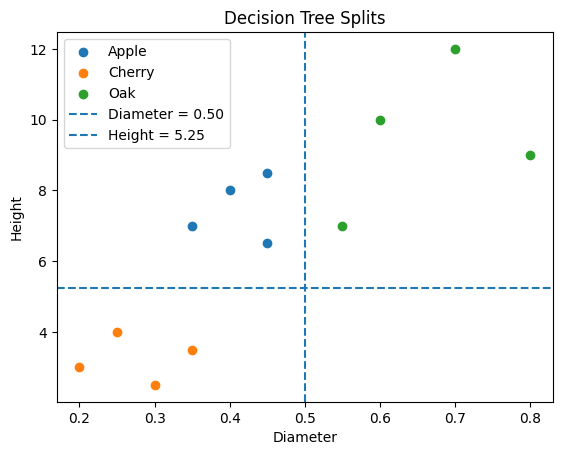

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Plot fruits
for fruit in np.unique(y):
    mask = y == fruit
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        label=fruit
    )

# First split: Diameter < 0.50
plt.axvline(
    x=0.50,
    linestyle="--",
    label="Diameter = 0.50"
)

# Second split: Height < 5.25
plt.axhline(
    y=5.25,
    linestyle="--",
    label="Height = 5.25"
)

plt.xlabel("Diameter")
plt.ylabel("Height")
plt.title("Decision Tree Splits")
plt.legend()
plt.show()